In [1]:
import torch
import torchphysics as tp
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""


/home/nick7/anaconda3/envs/bosch-pde/lib/python3.9/site-packages/pytorch_lightning/metrics/__init__.py:43: LightningDeprecationWarning: `pytorch_lightning.metrics.*` module has been renamed to `torchmetrics.*` and split off to its own package (https://github.com/PyTorchLightning/metrics) since v1.3 and will be removed in v1.5
  rank_zero_deprecation(


In [2]:
X = tp.spaces.R2('x')
T = tp.spaces.R1('t')

A1 = tp.domains.Circle(X, center=[0.5, 0.5], radius=0.5)
A2 = tp.domains.Circle(X, center=[0.5, 0.5], radius=lambda t: 0.5*t)
B = tp.domains.Interval(T, 0, 1)

C = (A1*B - A2*B)

points = C.sample_random_uniform(d=2000)

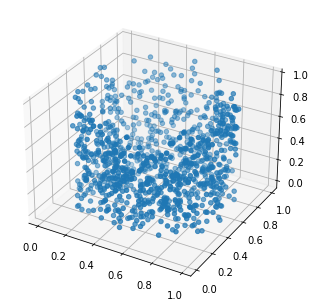

In [3]:
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

fig = pyplot.figure()
ax = Axes3D(fig)
ax.scatter(points[:,'x'].as_tensor[:,0], points[:,'x'].as_tensor[:,1], points[:,'t'].as_tensor)

In [4]:
sampler = tp.samplers.RandomUniformSampler(C, density=4000)

U = tp.spaces.R1('u')
model = tp.models.FCN(input_space=X*T, output_space=U, hidden=(20,20,20))

def residual(u, x, t):
    return tp.utils.laplacian(u, x)

condition = tp.conditions.PINNCondition(model,
                                        sampler,
                                        residual_fn=residual)

In [5]:
solver = tp.solver.Solver([condition])

import pytorch_lightning as pl

trainer = pl.Trainer(max_steps=100,
                     logger=False)
trainer.fit(solver)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name             | Type       | Params
------------------------------------------------
0 | train_conditions | ModuleList | 941   
1 | val_conditions   | ModuleList | 0     
------------------------------------------------
941       Trainable params
0         Non-trainable params
941       Total params
0.004     Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

RuntimeError: One of the differentiated Tensors appears to not have been used in the graph. Set allow_unused=True if this is the desired behavior.

In [29]:
len(sampler.sample_points())

2072

class RandomGenerator(torch.nn.Module):

conditions bekommen modelle als property und machen daraus torch.nn.ModuleList,
(Übergabe jeweils als Liste oder als dict möglich, falls in UserFunction Namen gebraucht werden)
dann bekommt solver nur die conditions, die schon alle nötigen modelle enthalten

in conditions können sampler definiert und oder aufgerufen werden
passiert dann alles automatisch auf dem richtigen device?
sampling wahrscheinlich schon, wie dataloader einbauen mit multiprocessing?
kann man einfach dataloader konstruieren und next aufrufen? -> könnte gehen
d.h. für conditions, die daten brauchen, definieren wir dataloader über ein dataset